# Laboratorio 7 — NLP end-to-end y Embeddings

**CC3092 Deep Learning y Sistemas Inteligentes** · Fernando Andree Hernández Martínez (23645) · Fernando José Rueda Rodas (23748)

Se construye un pipeline de NLP completo, **texto crudo → tokens → IDs → vectores → modelo → salida**:

1. Exploración y preprocesamiento de **WikiText-103** (normalización, tokenizador propio, ley de Zipf, vocabulario, submuestreo y pares skip-gram).
2. Investigación de `nn.Embedding`, `nn.EmbeddingBag` y de los modelos Word2Vec / GloVe.
3. Tres conjuntos de embeddings: **SGNS propio en PyTorch**, **Word2Vec de gensim** sobre el mismo corpus y **GloVe 6B-100d** preentrenado.
4. Verificación de la aritmética vectorial (analogías individuales, benchmark por categoría con 3CosAdd/3CosMul, t-SNE y paralelismo de vectores diferencia).
5. Clasificación de **AG News** con TF-IDF, embeddings aleatorios y embeddings preentrenados (congelados y con fine-tuning).

El código reutilizable vive en `src/` (`text.py`, `sgns.py`, `evaluation.py`, `classify.py`, `plots.py`); el notebook lo orquesta y discute los resultados.

In [1]:
import sys, json, platform, random, subprocess, time
from pathlib import Path

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from IPython.display import display, Image

import src.config as C
from src import text as T, sgns as S, evaluation as E, classify as K, plots as P

random.seed(C.SEED); np.random.seed(C.SEED); torch.manual_seed(C.SEED)
pd.set_option("display.max_colwidth", 120); pd.set_option("display.width", 200)
P.set_style()
DEVICE = S.get_device()
chip = subprocess.run(["sysctl", "-n", "machdep.cpu.brand_string"], capture_output=True, text=True).stdout.strip()
print("PyTorch", torch.__version__, "| dispositivo:", DEVICE, "|", chip or platform.processor(), "|", platform.platform())
import gensim, datasets, spacy, nltk, sklearn
print("gensim", gensim.__version__, "| datasets", datasets.__version__, "| spaCy", spacy.__version__,
      "| NLTK", nltk.__version__, "| scikit-learn", sklearn.__version__)

PyTorch 2.14.1 | dispositivo: mps | Apple M4 Pro | macOS-27.0.1-arm64-arm-64bit


gensim 4.4.0 | datasets 5.0.1 | spaCy 3.8.16 | NLTK 3.10.3 | scikit-learn 1.9.1


**Hardware.** Todo se ejecutó en un Apple **M4 Pro** (CPU de 14 núcleos, GPU integrada de 20 núcleos, 24 GB de memoria unificada). El SGNS propio se entrena en la GPU con el backend **MPS** de PyTorch; no hay CUDA, así que la memoria pico se mide muestreando `torch.mps.current_allocated_memory()` (en CUDA sería `torch.cuda.max_memory_allocated()`). Word2Vec de gensim corre en CPU con 12 hilos y los clasificadores de AG News en CPU (son modelos pequeños y la latencia de lanzar kernels en MPS no compensa).

## 1. Datos

| Recurso | Fuente | Uso |
|---|---|---|
| WikiText-103 (raw) | `load_dataset("Salesforce/wikitext", "wikitext-103-raw-v1")` | Corpus para entrenar los embeddings (split `train`) |
| AG News | `load_dataset("fancyzhx/ag_news")` | Clasificación de noticias en 4 clases |
| GloVe 6B-100d | `gensim.downloader.load("glove-wiki-gigaword-100")` | Embeddings preentrenados de referencia (Wikipedia 2014 + Gigaword 5, 6B tokens, 400k palabras) |
| `questions-words.txt` | `gensim.test.utils.datapath` | 19,544 analogías en 14 categorías (selección de modelos) |
| `wordsim353.tsv` | idem | 353 pares con similitud humana (selección de modelos) |
| `simlex999.txt` | idem | 999 pares, reservado para la evaluación final |

Los datos se descargan en `data/raw/` (no versionado) la primera vez; el corpus tokenizado se cachea en `data/processed/`.

## 2. Exploración y preprocesamiento del texto

### 2.1 Tamaño del corpus

WikiText-103 viene como una lista de líneas: títulos de artículo (` = Título = `), subtítulos (` = = Sección = = `), párrafos y líneas vacías. Un **artículo** empieza en un título de nivel 1 rodeado de líneas vacías (hay líneas de tablas con el mismo formato, p. ej. ` = Goals ; A = `, que no son títulos). Los **tokens** se cuentan de dos formas: separando por espacios el texto original (la cuenta oficial, que incluye puntuación) y con nuestro tokenizador (sin puntuación, ver 2.2).

In [2]:
from datasets import load_dataset
wiki = load_dataset("Salesforce/wikitext", "wikitext-103-raw-v1")
stats, corpus = T.prepare_wikitext()      # escaneo completo del train + subconjunto en IDs (cacheado)

rows = []
for split in ["train", "validation", "test"]:
    lines = wiki[split]["text"]
    kinds = pd.Series(T.classify_lines(lines)).value_counts()
    raw_tokens = sum(len(l.split()) for l in lines)
    ours = int(stats["tokens_per_line"].sum()) if split == "train" else \
        sum(len(T.tokenize(l)) for l, k in zip(lines, T.classify_lines(lines)) if k == "text")
    rows.append({"split": split, "artículos": kinds.get("article", 0), "líneas (filas)": len(lines),
                 "párrafos de texto": kinds.get("text", 0), "subtítulos": kinds.get("heading", 0),
                 "líneas vacías": kinds.get("empty", 0), "tokens (split por espacios)": raw_tokens,
                 "tokens (nuestro tokenizador)": ours})
size = pd.DataFrame(rows).set_index("split")
display(size.style.format("{:,}"))
print(f"Vocabulario del train completo con nuestro tokenizador: {len(stats['counter']):,} tipos")

,artículos,líneas (filas),párrafos de texto,subtítulos,líneas vacías,tokens (split por espacios),tokens (nuestro tokenizador)
split,,,,,,,
train,"28,472","1,801,350","860,934","275,623","636,321","101,425,671","84,614,118"
validation,60,"3,760","1,841",560,"1,299","213,886","179,562"
test,60,"4,358","2,187",644,"1,467","241,211","201,732"


Vocabulario del train completo con nuestro tokenizador: 716,855 tipos


**¿Cuántos artículos, líneas y tokens tiene el corpus?** El split de entrenamiento tiene **28,472 artículos** y **1,801,350 líneas** (860,934 párrafos de texto, 275,623 subtítulos y 636,321 líneas vacías). Separando por espacios hay **101.4M tokens** (la cifra oficial de 103.2M cuenta además un token de fin de línea por cada una de las 1.8M líneas); con nuestro tokenizador, que descarta la puntuación y reúne `role @-@ playing` en un token, quedan **84.6M tokens** y **716,855 tipos**. Validación y test son mucho más pequeños (60 artículos cada uno, ~0.2M tokens). Para entrenar usamos un **subconjunto de 25.0M tokens** (los primeros 8,478 artículos completos), por encima del mínimo de 20M que pide el laboratorio, para poder hacer 13 iteraciones en tiempo razonable.

### 2.2 Normalización

Las decisiones se tomaron para que el vocabulario sea **compatible con el de GloVe 6B** (tokenizado con el tokenizador de Stanford, todo en minúsculas), de modo que una palabra signifique lo mismo en los tres modelos y la comparación sea justa:

| Decisión | Qué hacemos | Por qué |
|---|---|---|
| Minúsculas | todo a minúsculas | GloVe 6B es *uncased*; si no, `France` y `france` serían palabras distintas y las preguntas de analogía (en mayúsculas) no coincidirían. |
| Separadores de WikiText | ` @-@ ` → `-`, ` @,@ ` → `,`, ` @.@ ` → `.` | WikiText parte `role-playing` y `102,779`; GloVe tiene `role-playing`, `e-mail`, `3.5` como un solo token. |
| Clíticos | `don't` → `do n't`, `game's` → `game 's` | Es la convención Penn Treebank que usa GloVe (`n't` y `'s` son tokens de su vocabulario). WikiText ya viene así; AG News no, así que se aplica la misma regla a ambos. |
| Acrónimos | `U.S.` → `u.s.` (se conserva el punto interno) | GloVe tiene `u.s.` como token frecuente. |
| Puntuación | se descarta | No aporta a las relaciones semánticas de los benchmarks y, al ser lo más frecuente, solo ocuparía ventanas de contexto. |
| Números | se conservan como tokens (`1990`, `1990s`, `3.5`, `1,000`) | GloVe tiene vectores para números; reemplazarlos por `<num>` crearía un token que GloVe no tiene. |
| Artefactos de AG News | `\`, `#39;`, `&lt;b&gt;`, etiquetas HTML | Restos del scraping (`#39;` es un apóstrofo escapado). |
| Tokens especiales | `<unk>` (palabras con frecuencia < `min_count`) y `<pad>` (relleno en el clasificador) | Ver 2.5. En SGNS las palabras fuera del vocabulario se **eliminan** del flujo antes de formar ventanas, igual que hacen word2vec y gensim. |

Las ventanas de contexto no cruzan párrafos ni artículos. Los títulos y subtítulos se descartan (son estructura, no prosa).

In [3]:
ejemplos = [
    " It is a tactical role @-@ playing game that sold 102 @,@ 779 units at 3 @.@ 5 dollars . \n",
    "Wall St. Bears Claw Back Into the Black (Reuters) Reuters - Short-sellers, Wall Street's dwindling\\band of ultra-cynics, are seeing green again.",
    "Google #39;s IPO: &lt;b&gt;Analysts&lt;/b&gt; don't expect the U.S. market to crash.",
]
for e in ejemplos:
    print("crudo      :", repr(e))
    print("normalizado:", T.normalize(e))
    print("tokens     :", T.tokenize(e), "\n")

crudo      : ' It is a tactical role @-@ playing game that sold 102 @,@ 779 units at 3 @.@ 5 dollars . \n'
normalizado: it is a tactical role-playing game that sold 102,779 units at 3.5 dollars .
tokens     : ['it', 'is', 'a', 'tactical', 'role-playing', 'game', 'that', 'sold', '102,779', 'units', 'at', '3.5', 'dollars'] 

crudo      : "Wall St. Bears Claw Back Into the Black (Reuters) Reuters - Short-sellers, Wall Street's dwindling\\band of ultra-cynics, are seeing green again."
normalizado: wall st. bears claw back into the black (reuters) reuters - short-sellers, wall street 's dwindling band of ultra-cynics, are seeing green again.
tokens     : ['wall', 'st', 'bears', 'claw', 'back', 'into', 'the', 'black', 'reuters', 'reuters', 'short-sellers', 'wall', 'street', "'s", 'dwindling', 'band', 'of', 'ultra-cynics', 'are', 'seeing', 'green', 'again'] 

crudo      : "Google #39;s IPO: &lt;b&gt;Analysts&lt;/b&gt; don't expect the U.S. market to crash."
normalizado: google 's ipo: analyst

### 2.3 Tokenizador propio contra spaCy y NLTK

Nuestro tokenizador es una expresión regular sobre el texto normalizado (`src/text.py`): acrónimos con punto, clíticos, números con formato y palabras con guion o apóstrofo internos. Se compara con `spaCy` (`en_core_web_sm`, solo el tokenizador) y `nltk.word_tokenize` (Treebank) en 12 oraciones. Para que la comparación se centre en la segmentación, a las salidas de las librerías se les aplica minúsculas y se les quita la puntuación.

In [4]:
import spacy, nltk
from nltk.tokenize import word_tokenize
nltk.download("punkt_tab", quiet=True)
nlp = spacy.load("en_core_web_sm", disable=["tagger", "parser", "ner", "lemmatizer", "attribute_ruler"])

oraciones = [
    "I don't think we can't finish it, but they'll try.",
    "The well-known state-of-the-art model is twenty-five years old.",
    "Dr. Smith moved to the U.S. in Jan. 2004, e.g. to work at IBM Corp.",
    "Prices rose 3.5% to $1,250.75 in the 1990s.",
    "She said: \"It's Sarah's book,\" and left.",
    "Email me at john.doe@example.com or visit https://example.com/page.",
    "The 2010–11 season (its 5th) was a re-run of the old pre-war rules.",
    "Mr. O'Neill's rock 'n' roll band played until 10 p.m.",
    "New York-based firms aren't hiring; LA-based ones are.",
    "We'd've gone if you'd asked—honestly!",
    "Valkyria Chronicles III is a tactical role-playing game for the PlayStation Portable.",
    "AT&T's CEO cut 1,000 jobs in Q3 vs. Q2 (approx. 12%).",
]
is_punct = lambda t: all(not ch.isalnum() for ch in t)
def lib_clean(toks):
    return [t.lower() for t in toks if not is_punct(t)]

rows = []
for s in oraciones:
    ours = T.tokenize(s)
    sp = lib_clean([t.text for t in nlp(s)])
    nl = lib_clean(word_tokenize(s))
    rows.append({"oración": s, "propio": " | ".join(ours), "spaCy": " | ".join(sp), "NLTK": " | ".join(nl),
                 "=spaCy": ours == sp, "=NLTK": ours == nl})
tok_cmp = pd.DataFrame(rows)
with pd.option_context("display.max_colwidth", 200):
    display(tok_cmp)
print(f"Coinciden con spaCy en {tok_cmp['=spaCy'].sum()}/12 y con NLTK en {tok_cmp['=NLTK'].sum()}/12 oraciones")

,oración,propio,spaCy,NLTK,=spaCy,=NLTK
0,"I don't think we can't finish it, but they'll try.",i | do | n't | think | we | ca | n't | finish | it | but | they | 'll | try,i | do | n't | think | we | ca | n't | finish | it | but | they | 'll | try,i | do | n't | think | we | ca | n't | finish | it | but | they | 'll | try,True,True
1,The well-known state-of-the-art model is twenty-five years old.,the | well-known | state-of-the-art | model | is | twenty-five | years | old,the | well | known | state | of | the | art | model | is | twenty | five | years | old,the | well-known | state-of-the-art | model | is | twenty-five | years | old,False,True
2,"Dr. Smith moved to the U.S. in Jan. 2004, e.g. to work at IBM Corp.",dr | smith | moved | to | the | u.s. | in | jan | 2004 | e.g. | to | work | at | ibm | corp,dr. | smith | moved | to | the | u.s. | in | jan. | 2004 | e.g. | to | work | at | ibm | corp.,dr. | smith | moved | to | the | u.s. | in | jan. | 2004 | e.g | to | work | at | ibm | corp,False,False
3,"Prices rose 3.5% to $1,250.75 in the 1990s.","prices | rose | 3.5 | to | 1,250.75 | in | the | 1990s","prices | rose | 3.5 | to | 1,250.75 | in | the | 1990s","prices | rose | 3.5 | to | 1,250.75 | in | the | 1990s",True,True
4,"She said: ""It's Sarah's book,"" and left.",she | said | it | 's | sarah | 's | book | and | left,she | said | it | 's | sarah | 's | book | and | left,she | said | it | 's | sarah | 's | book | and | left,True,True
5,Email me at john.doe@example.com or visit https://example.com/page.,email | me | at | john | doe | example | com | or | visit | https | example | com | page,email | me | at | john.doe@example.com | or | visit | https://example.com/page,email | me | at | john.doe | example.com | or | visit | https | //example.com/page,False,False
6,The 2010–11 season (its 5th) was a re-run of the old pre-war rules.,the | 2010 | 11 | season | its | 5th | was | a | re-run | of | the | old | pre-war | rules,the | 2010–11 | season | its | 5th | was | a | re | run | of | the | old | pre | war | rules,the | 2010 | 11 | season | its | 5th | was | a | re-run | of | the | old | pre-war | rules,False,True
7,Mr. O'Neill's rock 'n' roll band played until 10 p.m.,mr | o'neill | 's | rock | n | roll | band | played | until | 10 | p.m.,mr. | o'neill | 's | rock | n | roll | band | played | until | 10 | p.m.,mr. | o'neill | 's | rock | 'n | roll | band | played | until | 10 | p.m,False,False
8,New York-based firms aren't hiring; LA-based ones are.,new | york-based | firms | are | n't | hiring | la-based | ones | are,new | york | based | firms | are | n't | hiring | la | based | ones | are,new | york-based | firms | are | n't | hiring | la-based | ones | are,False,True
9,We'd've gone if you'd asked—honestly!,we | 'd | 've | gone | if | you | 'd | asked | honestly,we | 'd | 've | gone | if | you | 'd | asked | honestly,we'd | 've | gone | if | you | 'd | asked | honestly,True,False


Coinciden con spaCy en 4/12 y con NLTK en 7/12 oraciones


**¿En qué casos difieren?** Coincidimos con NLTK en 7/12 oraciones y con spaCy en 4/12. Los tres separan igual los **clíticos** (`do n't`, `ca n't`, `'ll`, `'s`), porque siguen la convención Penn Treebank.
- **Guiones:** spaCy parte `well-known`, `state-of-the-art`, `role-playing`, `re-run` y `York-based` en piezas; nosotros y NLTK los dejamos como un token (como GloVe). Esta es la mayor fuente de diferencias con spaCy.
- **Abreviaturas:** spaCy y NLTK conservan el punto en `dr.`, `jan.`, `corp.`, `vs.`; nosotros lo quitamos salvo en acrónimos con varios puntos (`u.s.`, `e.g.`, `p.m.`). GloVe tiene ambas formas, así que no perdemos cobertura.
- **URLs, correos y símbolos:** spaCy mantiene `john.doe@example.com`, `https://example.com/page` y `at&t` enteros; nosotros los partimos en palabras (para embeddings de palabras es preferible: `example` y `com` sí tienen vector).
- **Casos raros:** `2010–11` con raya larga (spaCy no lo parte), `'n'` de *rock 'n' roll* (NLTK deja `'n`), `we'd've` (NLTK deja `we'd`).

El tokenizador propio es más simple que spaCy, pero produce exactamente la segmentación que necesitamos para compartir vocabulario con GloVe.

### 2.4 Ley de Zipf

Se usa el **subconjunto de entrenamiento**: los primeros artículos completos de WikiText-103 hasta superar 25 millones de tokens (ver 4). La ley de Zipf predice $f(r) \propto r^{-s}$ con $s \approx 1$: una recta de pendiente −1 en escala log-log.

Subconjunto: 8,478 artículos, 255,175 párrafos, 25,002,277 tokens, 352,393 tipos


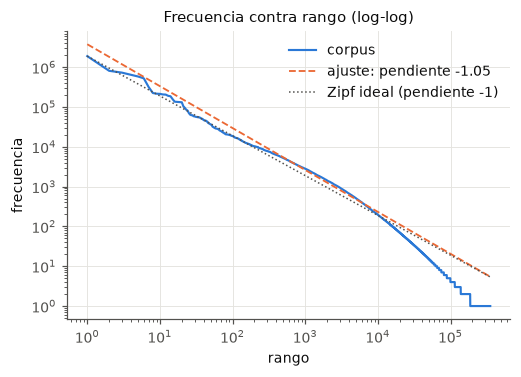

,subconjunto (25M),train completo (84.6M)
top 10,24.6 %,24.6 %
"top 1,000",64.0 %,64.0 %
"top 30,000",94.9 %,94.6 %


Pendiente ajustada (rangos 10–10,000): -1.053
Hapax legomena (frecuencia 1): 166040 = 47.1 % del vocabulario


In [5]:
print(f"Subconjunto: {stats['subset_articles']:,} artículos, {len(corpus.starts) - 1:,} párrafos, "
      f"{corpus.n_tokens:,} tokens, {len(corpus.words):,} tipos")
slope, intercept = T.zipf_fit(corpus.counts)
fig = P.zipf(corpus.counts, slope, intercept); plt.show()
cov = T.coverage(corpus.counts)
full_counts = np.array(sorted(stats["counter"].values(), reverse=True))
cov_full = T.coverage(full_counts)
display(pd.DataFrame({"subconjunto (25M)": {f"top {k:,}": f"{100 * v:.1f} %" for k, v in cov.items()},
                      "train completo (84.6M)": {f"top {k:,}": f"{100 * v:.1f} %" for k, v in cov_full.items()}}))
print(f"Pendiente ajustada (rangos 10–10,000): {slope:.3f}")
print("Hapax legomena (frecuencia 1):", int((corpus.counts == 1).sum()), f"= {100 * (corpus.counts == 1).mean():.1f} % del vocabulario")

**¿Se cumple la ley de Zipf?** Sí, de forma muy clara: en log-log la curva es casi una recta, con **pendiente ajustada de −1.05** en los rangos 10–10,000 (Zipf ideal: −1). Se desvía en los extremos, como es usual: las primeras palabras están algo por debajo de la recta y la cola de hapax forma escalones (frecuencias enteras pequeñas).

**Cobertura:** las **10** palabras más frecuentes (`the, of, and, in, to, a, was, on, as, 's`) cubren el **24.6 %** de todos los tokens; las **1,000** más frecuentes, el **64.0 %**; y las **30,000**, el **94.9 %** (94.6 % en el train completo). En el otro extremo, el **47 % del vocabulario son hapax** (aparecen una sola vez). Pocas palabras concentran casi todo el texto y la mayoría del vocabulario aparece tan poco que no se puede aprender un vector útil para ella. De ahí el `min_count` y el submuestreo.

### 2.5 Vocabulario y `min_count`

Con un umbral `min_count`, las palabras menos frecuentes se vuelven `<unk>`. Como los IDs están ordenados por frecuencia, el vocabulario con umbral $m$ son los IDs con frecuencia $\geq m$.

In [6]:
vt = pd.DataFrame(T.vocab_table(corpus.counts)).set_index("min_count")
display(vt.style.format({"vocab": "{:,}", "tokens_unk_%": "{:.2f} %"}))

,vocab,tokens_unk_%
min_count,,
1,"352,393",0.00 %
2,"186,353",0.66 %
5,"99,347",1.57 %
10,"65,443",2.46 %
20,"43,497",3.65 %
50,"24,785",5.98 %
100,"15,875",8.47 %


Con `min_count = 1` el vocabulario tiene 352,393 palabras; con **5** baja a **99,347** (−72 %) y solo el **1.57 %** de los tokens se vuelven desconocidos; con 20, 43,497 palabras y 3.65 % de `<unk>`; con 100, 15,875 palabras y 8.47 %. Usamos **`min_count = 5`** (el valor por defecto de word2vec): elimina la cola de palabras con muy poca evidencia, que además serían las más ruidosas, y conserva casi todo el texto. La iteración S13 prueba `min_count = 20`.

### 2.6 Submuestreo de palabras frecuentes

Word2Vec descarta cada aparición de una palabra $w$ con frecuencia relativa $f(w)$ con probabilidad $P_{desc}(w)$. El paper (Mikolov et al., 2013) usa $P_{desc} = 1 - \sqrt{t/f(w)}$; el código C de word2vec y gensim usan $P_{conservar} = (\sqrt{f/t} + 1)\, t/f$, algo menos agresiva. Usamos la segunda (la misma de gensim, para que ambas implementaciones vean el mismo corpus en promedio) con $t = 10^{-4}$, y se aplica sobre el vocabulario con `min_count = 5`.

In [7]:
base = corpus.restrict(5)
keep = T.keep_probability(base.counts, 1e-4)
f = base.counts / base.counts.sum()
paper = np.clip(1 - np.sqrt(1e-4 / f), 0, 1)
rng = np.random.default_rng(C.SEED)
mask = rng.random(base.n_tokens) < keep[base.ids]
rows = []
for w in ["the", "of", "and", "in", "was", "king", "computer", "france"]:
    i = base.words.index(w)
    occ = base.ids == i
    rows.append({"palabra": w, "frecuencia": int(base.counts[i]), "f (relativa)": f[i],
                 "% descartado (gensim/C)": 100 * (1 - keep[i]), "% descartado (paper)": 100 * paper[i],
                 "% descartado (muestra real)": 100 * (1 - mask[occ].mean())})
display(pd.DataFrame(rows).style.format({"frecuencia": "{:,}", "f (relativa)": "{:.5f}",
        "% descartado (gensim/C)": "{:.1f}", "% descartado (paper)": "{:.1f}", "% descartado (muestra real)": "{:.1f}"}))
print(f"Tokens: {base.n_tokens:,} -> {mask.sum():,} tras el submuestreo ({100 * (1 - mask.mean()):.1f} % descartado)")

,palabra,frecuencia,f (relativa),% descartado (gensim/C),% descartado (paper),% descartado (muestra real)
0,the,"1,892,657",0.07691,96.3,96.4,96.3
1,of,"809,638",0.03290,94.2,94.5,94.2
2,and,"728,565",0.02961,93.9,94.2,93.8
3,in,"640,280",0.02602,93.4,93.8,93.4
4,was,"316,584",0.01286,90.4,91.2,90.4
5,king,"9,979",0.00041,25.7,50.3,25.5
6,computer,"1,663",0.00007,0.0,0.0,0.0
7,france,"4,875",0.00020,0.0,29.0,0.0


Tokens: 24,608,578 -> 14,781,282 tras el submuestreo (39.9 % descartado)


**¿Qué porcentaje se descarta?** Con $t = 10^{-4}$ se descarta el **96.3 % de las apariciones de `the`**, el **94.2 % de `of`** y el **93.9 % de `and`** (la muestra real coincide con la probabilidad teórica). Palabras de contenido como `computer` o `france` (f < $t$) no se tocan, y `king` pierde un 26 %. En total se descarta el **39.9 % de los tokens** (24.6M → 14.8M por epoch).

**¿Por qué ayuda?**
1. **Información:** que `france` aparezca junto a `the` no dice casi nada (`the` co-ocurre con todo); que aparezca junto a `paris` sí. Al quitar la mayoría de las palabras funcionales, los pares de entrenamiento se concentran en co-ocurrencias informativas.
2. **Ventana efectiva más grande:** como se submuestrea antes de formar ventanas, los vecinos que quedan están más lejos en el texto original.
3. **Velocidad:** ~40 % menos tokens y pares por epoch, es decir, epochs ~40 % más rápidos.
4. **Equilibrio:** sin submuestreo, los vectores de las palabras más frecuentes recibirían millones de actualizaciones y dominarían el gradiente; Mikolov et al. reportan mejores vectores para palabras raras.

### 2.7 Pares (palabra central, contexto) para skip-gram

Cada token genera un par por cada vecino dentro de la ventana (sin cruzar párrafos). Con ventana fija $c$, un párrafo de longitud $L$ produce $\sum_{d=1}^{c} 2\max(L-d, 0)$ pares. Word2Vec usa una **ventana dinámica** (para cada centro se muestrea $b \sim U\{1..c\}$), que equivale a ponderar los contextos cercanos y deja en promedio una fracción $(c+1)/(2c)$ de los pares (60 % con $c=5$). Abajo se reportan ambos, antes y después del submuestreo, con $c = 5$. Al submuestrear antes de formar ventanas, la ventana efectiva se agranda: las palabras que quedan están, en promedio, más lejos en el texto original.

In [8]:
def starts_after(mask, starts):
    ck = np.concatenate([[0], np.cumsum(mask)])
    return ck[starts]

sub_starts = starts_after(mask, base.starts)
W = 5
pairs = pd.DataFrame({
    "tokens": [base.n_tokens, int(mask.sum())],
    "pares (ventana fija c=5)": [T.count_pairs(base.starts, W), T.count_pairs(sub_starts, W)],
    "pares esperados (ventana dinámica, b~U{1..5})": [T.expected_pairs_dynamic(base.starts, W),
                                                      T.expected_pairs_dynamic(sub_starts, W)],
}, index=["antes del submuestreo", "después del submuestreo"])
display(pairs.style.format("{:,}"))

# Los pares reales se generan en la GPU (src/sgns.make_pairs); un epoch de ejemplo:
ids_t = torch.tensor(base.ids, device=DEVICE); para_t = torch.tensor(base.para_ids, device=DEVICE)
kp_t = torch.tensor(keep, dtype=torch.float32, device=DEVICE)
torch.manual_seed(C.SEED)
cen, ctx, n_sub = S.make_pairs(ids_t, para_t, kp_t, W, DEVICE)
print(f"Epoch de ejemplo en la GPU: {len(cen):,} pares de {n_sub:,} tokens submuestreados")
print("Primeros pares:", [(base.words[a], base.words[b]) for a, b in zip(cen[:8].tolist(), ctx[:8].tolist())])
del ids_t, para_t, kp_t, cen, ctx; S.free_memory(DEVICE)

,tokens,pares (ventana fija c=5),"pares esperados (ventana dinámica, b~U{1..5})"
antes del submuestreo,"24,608,578","238,556,764","144,123,030"
después del submuestreo,"14,781,282","140,323,116","85,173,042"


Epoch de ejemplo en la GPU: 85,181,560 pares de 14,782,105 tokens submuestreados
Primeros pares: [('senjō', 'valkyria'), ('valkyria', '3'), ('3', 'unrecorded'), ('unrecorded', 'chronicles'), ('chronicles', 'japanese'), ('japanese', 'lit'), ('lit', 'valkyria'), ('valkyria', 'battlefield')]


**Pares por epoch.** Con ventana fija $c=5$ el corpus produce **238.6M pares** por epoch antes del submuestreo y **140.3M** después. Con la ventana dinámica de word2vec, que es la que usamos, se esperan **144.1M** antes y **85.2M** después; el epoch real generado en la GPU tiene **85.2M pares**. Es decir, el submuestreo reduce los pares un 41 % y la ventana dinámica otro 40 %.